In [15]:
import numpy as np
import pandas as pd 
import cv2
import matplotlib.pyplot as plt
import easyocr
reader = easyocr.Reader(['en'], gpu=False)

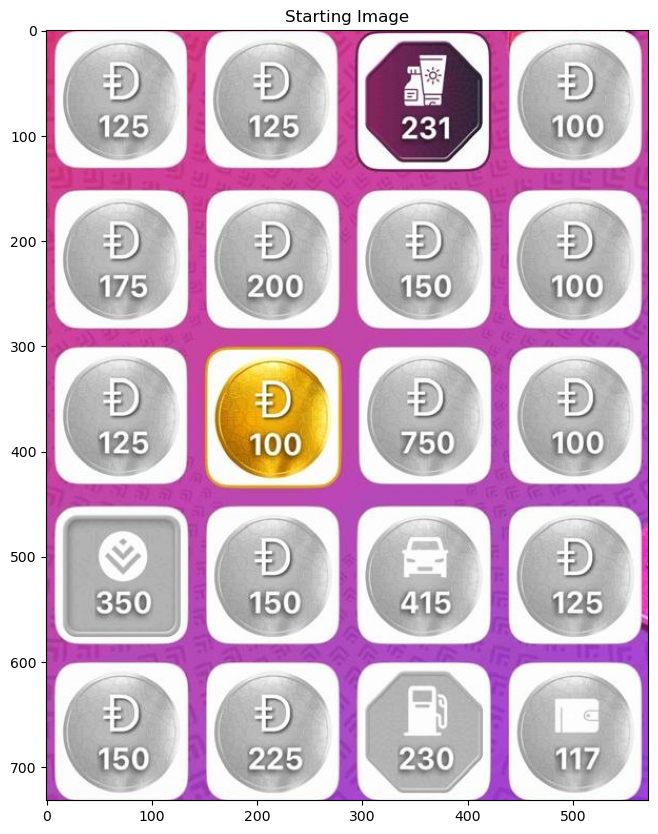

In [153]:
path = '../data/images/Image2.jpeg'
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.title("Starting Image")
plt.show()

In [154]:
#test_tile = img_rgb[1:150, 50:150]
#plt.imshow(test_tile)
#plt.show

In [157]:
#test_tile2 = img_rgb[150:275, 180:280]
#plt.imshow(test_tile2)
#plt.show

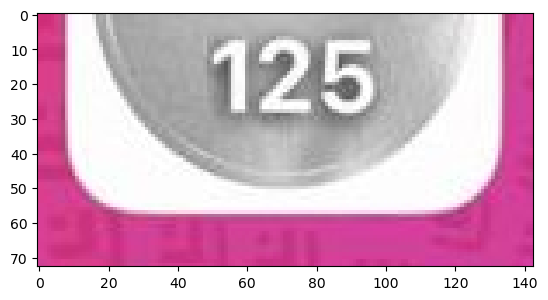

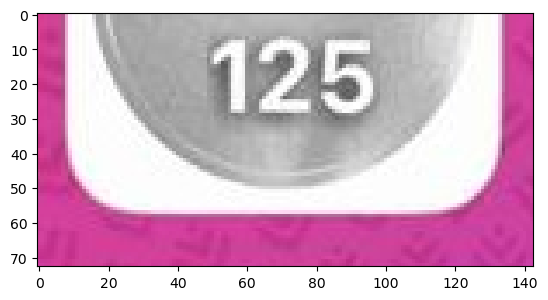

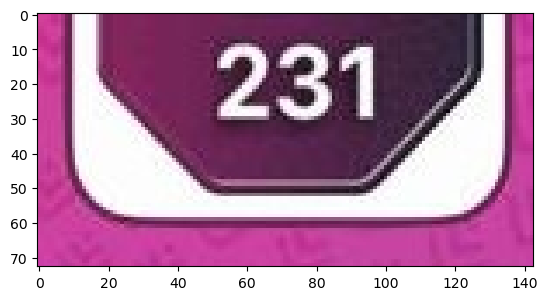

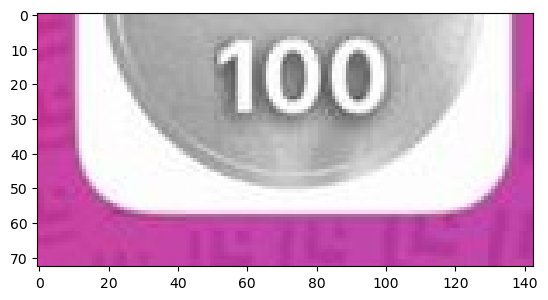

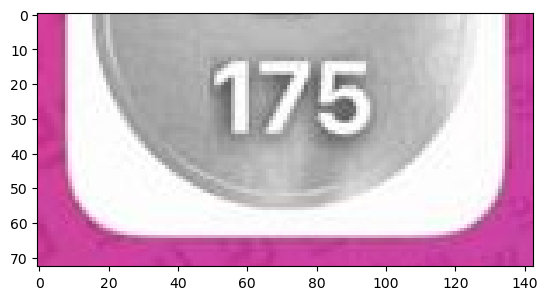

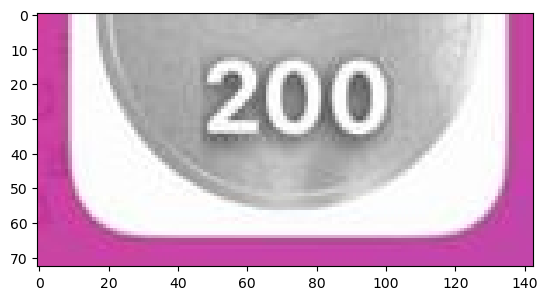

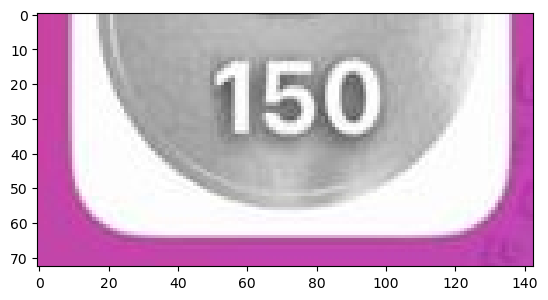

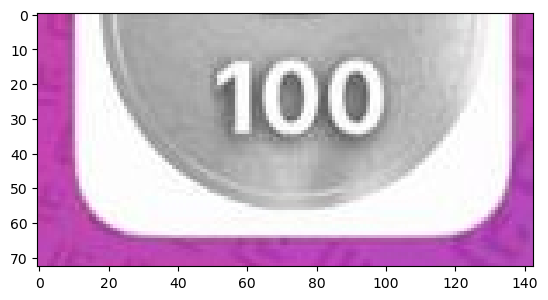

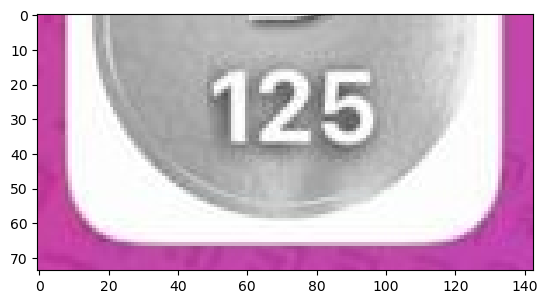

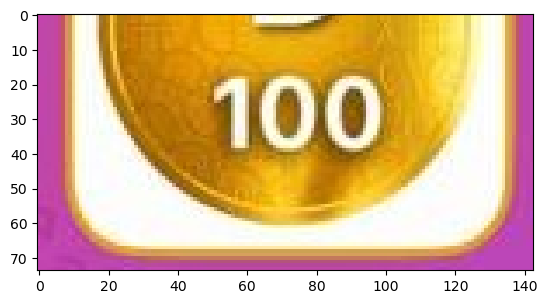

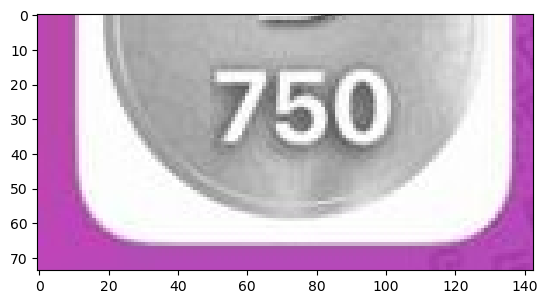

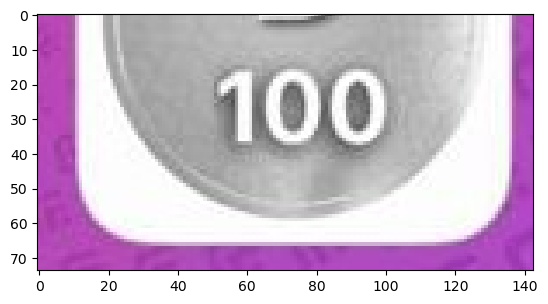

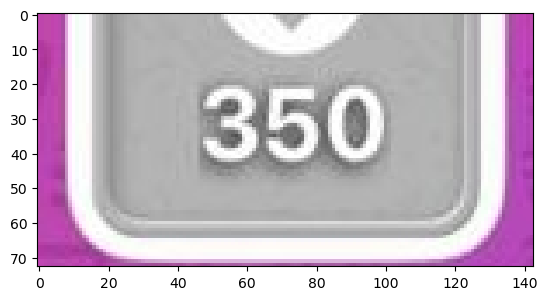

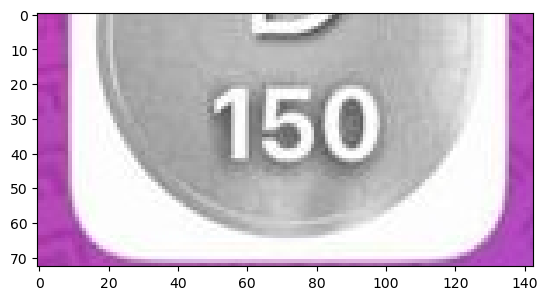

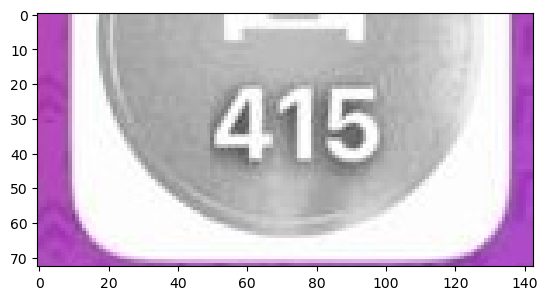

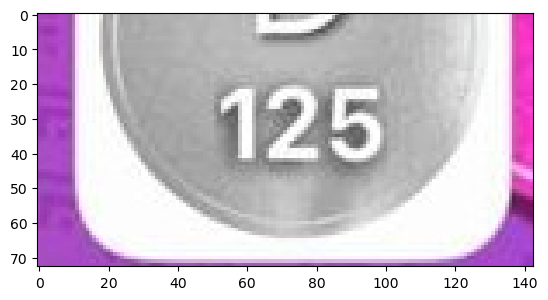

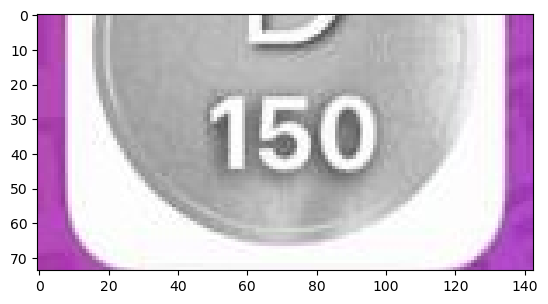

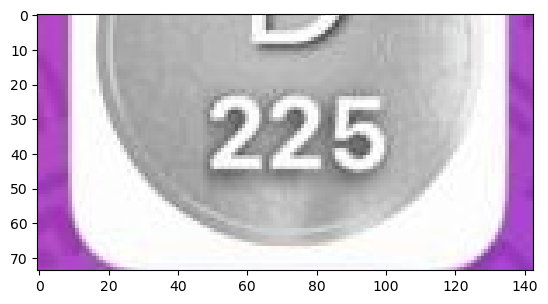

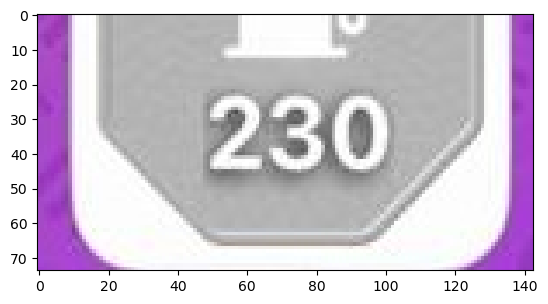

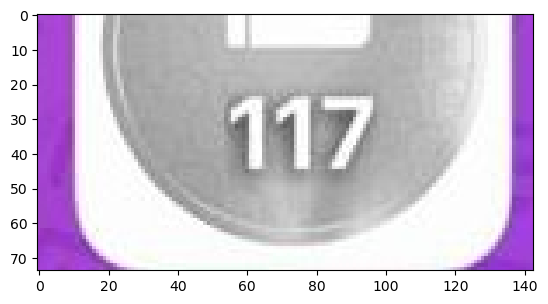

In [159]:
height, width, _ = img_rgb.shape
rows = 5 
cols = 4

## split image intp 5 by 4 grid - requires cropped screenshot to be uploaded 
row_step = height / rows 
col_step = width / cols
numbers = []
for r in range(rows):
    for c in range(cols):
        y1, y2 = r * row_step, (r +1) * row_step
        x1, x2 = c * col_step, (c +1) * col_step

        tile = img_rgb[int(y1):int(y2), int(x1):int(x2)]
        ## exract bottom part with number
        t_h, t_w, _ = tile.shape
        number = tile[int(t_h * 0.5):t_h, 0:t_w]
        numbers.append(number)
        plt.imshow(number)
        plt.show()
        

        

In [162]:
def number_extractor(image):
    gray_tile = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_tile, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    padding = 15
    padded_tile = cv2.copyMakeBorder(
        thresh, 
        padding, padding, padding, padding, 
        cv2.BORDER_CONSTANT, 
        value=[255, 255, 255]
    )
    upscaled = cv2.resize(padded_tile, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    results = reader.readtext(upscaled)
    if not results:
        return None 
    text = results[0][1]
    clean = ''.join(filter(str.isdigit, text))
    return int(clean) if clean else None
for i in range(20):
    value = number_extractor(numbers[i])
    print(f'OCR got {value}')



OCR got 125
OCR got 125
OCR got 231
OCR got 160
OCR got 175
OCR got 200
OCR got 150
OCR got 100
OCR got 125
OCR got 100
OCR got 750
OCR got 100
OCR got 350
OCR got 150
OCR got 415
OCR got 125
OCR got 150
OCR got 225
OCR got 230
OCR got 117


In [ ]:
import sys
import os
# This line allows you to import from the src folder
sys.path.append(os.path.abspath('../')) 

from src.db_manager import save_results

# After your OCR loop finishes and you have 'all_rewards' (a list of 20 ints)
# save_results(all_rewards, "path/to/image.png")

In [ ]:
import pandas as pd

def get_historical_data():
    """Pulls all square values into a single clean DataFrame."""
    query = "SELECT * FROM square_values"
    # We use the engine we already created
    df = pd.read_sql(query, con=engine)
    return df